# 1. Libraries

In [ ]:
!pip install stanza langdetect

import pandas as pd
import math
import numpy as np
import json

from langdetect import detect
import stanza
stanza.download('id')

stanza_nlp = stanza.Pipeline('id')

2026-04-28 16:07:45 INFO: Downloaded file to /home/lenovo/.cache/stanza/1.11.0/resources/resources.json
2026-04-28 16:07:45 INFO: Downloading default packages for language: id (Indonesian) ...
2026-04-28 16:07:46 INFO: File exists: /home/lenovo/.cache/stanza/1.11.0/resources/id/default.zip
2026-04-28 16:07:49 INFO: Finished downloading models and saved to /home/lenovo/.cache/stanza/1.11.0/resources
2026-04-28 16:07:49 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-28 16:07:49 INFO: Downloaded file to /home/lenovo/.cache/stanza/1.11.0/resources/resources.json
2026-04-28 16:07:49 INFO: Loading these models for language: id (Indonesian):
| Processor    | Package      |
-------------------------------
| tokenize     | gsd          |
| mwt          | gsd          |
| pos          | gsd_charlm   |
| lemma        | gsd_nocharlm |
| constitu

# 2. Getting Data

In [7]:
df = pd.read_csv("../outputs/dataset_preprocessed.csv")

# 3. See Language

In [8]:
for index, row in df.iterrows():
    text = row["konten_preprocessed"]
    lang = detect(text)
    print(f"Language: {lang}")

Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: en
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id

# 4. Execute POS Tagging

In [ ]:
df["tokens"] = [[] for _ in range(len(df))]

for index, row in df.iterrows():
    c = stanza_nlp(text)
    
    for sentence in doc.sentences:
        for word in sentence.words:
            df.loc[index, "tokens"].append((word.text, word.upos))


# 5. Save to JSON

In [10]:
# create a copy and save the POS as json
df_output = df.copy()
df_output["tokens_json"] = df_output["tokens"].apply(json.dumps)
df_output = df_output.drop(columns=["tokens"])
df_output.to_csv("../outputs/part_of_speech.csv", index=False)

# 6. Analyze Article 10

In [11]:
selected_df = df.iloc[9]

text = " ".join(f"({word}, {pos})" for word, pos in selected_df["tokens"])
print(text)

(indonesia, PROPN) (perintah, NOUN) (relaksasi, NOUN) (wajib, NOUN) (tingkat, NOUN) (komponen, NOUN) (negeri, NOUN) (tkdn, NOUN) (produk, NOUN) (impor, NOUN) (amerika, PROPN) (serikat, PROPN) (batas, NOUN) (barang, NOUN) (sektor, NOUN) (industri, NOUN) (teknologi, NOUN) (informasi, NOUN) (komunikasi, NOUN) (ict, NOUN) (relaksasi, NOUN) (tkdn, NOUN) (barang, NOUN) (industri, NOUN) (ict, NOUN) (bijak, ADJ) (bawa, NOUN) (perintah, NOUN) (negosiasi, NOUN) (tarif, NOUN) (dagang, VERB) (kena, ADP) (presiden, NOUN) (donald, NOUN) (trump, PROPN) (indonesia, PROPN) (negosiasi, NOUN) (jadwal, NOUN) (washington, NOUN) (dc, X) (april, PROPN) (tkdn, NOUN) (kait, NOUN) (ict, NOUN) (menteri, NOUN) (koordinator, NOUN) (bidang, NOUN) (ekonomi, NOUN) (airlangga, NOUN) (hartarto, NOUN) (kantor, NOUN) (kemenko, NOUN) (ekonomi, NOUN) (pusat, NOUN) (senin, NOUN) (nyata, NOUN) (wakil, NOUN) (menteri, NOUN) (investasi, NOUN) (hilir, NOUN) (wakil, NOUN) (kepala, NOUN) (badan, NOUN) (koordinasi, NOUN) (tanam, N

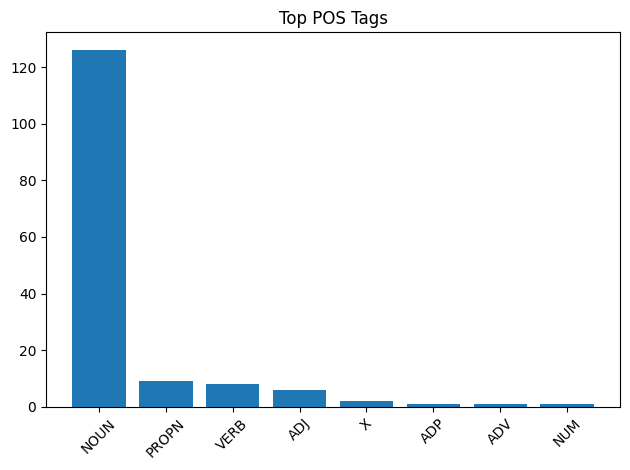

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

pos_counts = Counter(token[1] for token in selected_df["tokens"])
top_pos = dict(pos_counts.most_common())

plt.figure()
plt.title("Top POS Tags")
plt.bar(top_pos.keys(), top_pos.values())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()